<img src='https://hammondm.github.io/hltlogo1.png' style="float:right">
LING 581: Advanced Computational Linguistics<br>
Davo Acevedo-Cardona

# TERM PROJECT:
# Comparing Word Similarity in English and Spanish with WordNet and Word Embeddings with SpaCy

## Introduction:

This project contrasts two simple approaches to measuring semantic similarity between words:

- Symbolic similarity using WordNet's cognitive lexical network
- Statistical similarity derived from distributional word embeddings

WordNet represents lexical relationships through synsets stored as semantic hierarchies with explicit taxonomic relations. On the other hand, Word embeddings such as SpaCy's own vectors (or GloVe) represent words as high-dimensional numerical vectors with dense representations of semantic relationships implicit in their distributional patterns within large text corpora.

By comparing both methods on a few bank word in English and Spanish, this study aims to compare systematically to what degree similarity judgments overlap between languages and methods.

## Research Question:

Do WordNet WUP similarity and SpaCy's embedding-based cosine similarity scores remain consistent across English and Spanish? If so, to what extent do similarity judgments overlap between the two languages and methods?

## Approach:

To answer the reseach question we plan to:

- Select a bank of word pairs spanning various semantic relationships.
- Calculate similarity using WordNet path-based measures in both languages.
- Compute vector cosine similarity using pre-trained embeddings with SpaCy.
- Plot the results of both mothods in English and Spanish.
- Analyze cross-lingual and cross-methodological correlations.

# 1. Set-up

In [1]:
# Imports
import nltk
import spacy
import matplotlib.pyplot as plt
from nltk.corpus import wordnet as wn
from scipy.spatial.distance import cosine

In [2]:
# Resources
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/hanniaodetterojasbarreda/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/hanniaodetterojasbarreda/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
#Spacy Models:
#Download the models:
#!python -m spacy download en_core_web_md
#!python -m spacy download es_core_news_md

In [4]:
#Call the models
nlp_en = spacy.load("en_core_web_md")  # English model with embeddings
nlp_es = spacy.load("es_core_news_md")  # Spanish model with embeddings

## 1.1 Word banks:

In [5]:
#English words
en_words = [('cat', 'dog'),
                 ('run', 'jog'),
                 ('car', 'bus'),
                 ('big', 'large'),
                 ('love', 'hate')]
#Spanish words
es_words = [('gato', 'perro'),
                 ('correr', 'trotar'),
                 ('coche', 'autobús'),
                 ('grande', 'enorme'),
                 ('amor', 'odio')]

# 2. Functions:

## 2.1. WordNet Similarity via Wu-Palmer similarity

In [6]:
# DEFINE THE HELPER FUNCTION:

def wup_similarity(w1, w2, lang):
    """
    Compute the Wu–Palmer (WUP) semantic similarity between two words using WordNet.
    
    Parameters:
    w1 : str
        The first word whose similarity will be computed.
    w2 : str
        The second word whose similarity will be computed.
    lang : str
        Variable to switch between languages (e.g., 'eng' for English, 'spa' for Spanish).

    Returns:
    float
        The highest Wu–Palmer similarity score between any synset pair associated with the two words.
    """
    
    # Get all synsets for each word in the specified language
    syn1 = wn.synsets(w1, lang=lang)
    syn2 = wn.synsets(w2, lang=lang)
    
    max_sim = 0  # Empty value to calculate the maximum WUP Similarity

    #"for" cycle to loop all the synsets:
    for s1 in syn1:
        for s2 in syn2:
            if s1.pos() == s2.pos(): # Ensure same POS Tag
                sim = s1.wup_similarity(s2)
                if sim and sim > max_sim: #Conditional to update the value of max_sin
                    max_sim = sim
    
    return max_sim

### Results:

In [7]:
#English
print("English WUP Similarity:")
for w1, w2 in en_words:
    sim = wup_similarity(w1, w2, lang='eng')
    print(f"{w1} - {w2} = {sim:.3f}")

#Spanish
print("\nSpanish WUP Similarity:")
for w1, w2 in es_words:
    sim = wup_similarity(w1, w2, lang='spa')
    print(f"{w1} - {w2} = {sim:.3f}")

English WUP Similarity:
cat - dog = 0.857
run - jog = 0.900
car - bus = 0.960
big - large = 1.000
love - hate = 0.857

Spanish WUP Similarity:
gato - perro = 0.857
correr - trotar = 0.000
coche - autobús = 0.737
grande - enorme = 0.500
amor - odio = 0.857


## 2.2. Embedding Cosine Similarity using SpaCy

In [8]:
# DEFINE THE HELPER FUNCTION:

def spacy_cos(w1, w2, lang):
    """
    Compute cosine similarity between two words using SpaCy word embeddings.

    This function selects the appropriate SpaCy language model (English or Spanish),
    tokenizes each input word, and retrieves their associated vector embeddings.

    Parameters:
    w1 : str
        The first word whose similarity will be computed.
    w2 : str
        The second word whose similarity will be computed.
    lang : str
        Variable to switch between languages (e.g., 'eng' for English, 'spa' for Spanish).

    Returns:
    float 
        The cosine similarity score between the two word embeddings.
    """
    
    nlp = nlp_en if lang == 'eng' else nlp_es #Choose the right model (ENG or ESP)

    #Tokenization of the words
    token1 = nlp(w1)[0] 
    token2 = nlp(w2)[0]
    
    # Cosine Calculation:
    if token1.has_vector and token2.has_vector: #Make sure to have fullfilled vectors
        return (1 - cosine(token1.vector, token2.vector)) #In spacy distance = 1 − cos(O°)
    else:
        return None

### Results:

In [9]:
# English
print("English Cosine Similarity:")
for w1, w2 in en_words:
    sim = spacy_cos(w1, w2, lang='eng')
    print(f"{w1} - {w2} = {sim:.3f}")

#Spanish
print("\nSpanish Cosine Similarity:")
for w1, w2 in es_words:
    sim = spacy_cos(w1, w2, lang='spa')
    print(f"{w1} - {w2} = {sim:.3f}")

English Cosine Similarity:
cat - dog = 1.000
run - jog = 0.507
car - bus = 0.210
big - large = 1.000
love - hate = 1.000

Spanish Cosine Similarity:
gato - perro = 0.849
correr - trotar = 1.000
coche - autobús = 0.655
grande - enorme = 0.679
amor - odio = 0.520


# 3. Plot the Results:

## 3.1 Values

In [10]:
en_words = ['cat-dog', 'run-jog', 'car-bus', 'big-large', 'love-hate']
en_wup = [0.857, 0.9, 0.96, 1, 0.857]
en_cos = [1, 0.507, 0.210, 1, 1]

es_words = ['gato-perro', 'correr-trotar', 'coche-autobús', 'grande-enorme', 'amor-odio']
es_wup = [0.857, 0, 0.737, 0.5, 0.857]
es_cos = [0.849, 1, 0.655, 0.679, 0.52]

## 3.2 Plots:

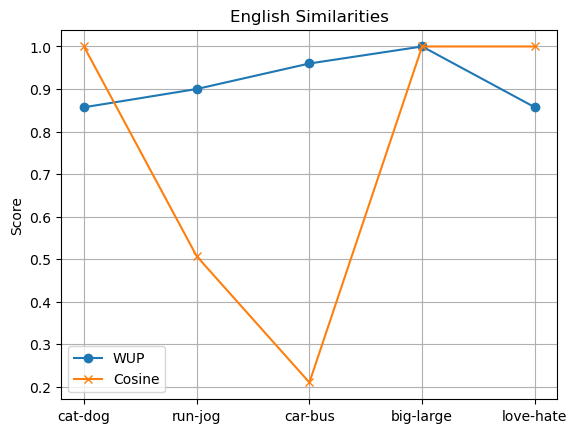

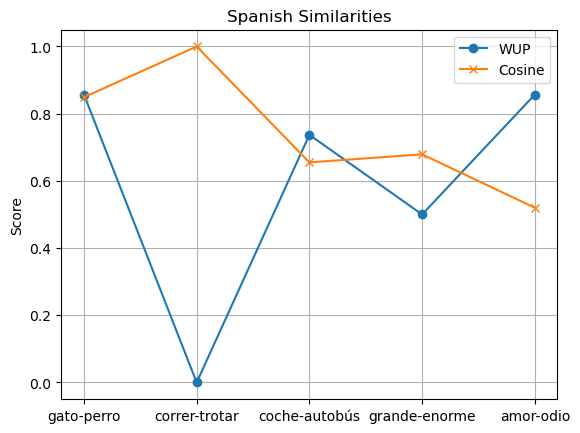

In [11]:
# English
plt.plot(en_words, en_wup, marker='o', label='WUP')
plt.plot(en_words, en_cos, marker='x', label='Cosine')
plt.title("English Similarities")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

# Spanish
plt.plot(es_words, es_wup, marker='o', label='WUP')
plt.plot(es_words, es_cos, marker='x', label='Cosine')
plt.title("Spanish Similarities")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

# Analisys:

## Cross-linguistic Comparison:

### English Plot:
There is a relatively high correlation between WUP and cosine similarity scores for most of word pairs, with some notable patterns:

- Pairs such as "big-large" and "cat-dog" have high scores on both measures, demostrating strong synonymy or shared taxonomic classes. This suggests an alignment between the way WordNet captures conceptual relations and the way those relations occur in distributional patterns.
- For words such as "Run-jog" and "car-bus", WordNet shows divergence between the models. WUP scores are high (0.9 and 0.96) reflecting shared hypernyms in the taxonomic structure, while cosine similarity scores are much lower (0.507 and 0.21). This discrepancy can be attributed to differences in usage contexts and frequencies differ across the training corpora.
- An interesting case arises with word pairs like "love-hate", which are antonyms yet have a cosine similarity score of 1.0. This demonstrate that word embeddings tend to capture contextual co-occurrence rather than true semantic similarity. In contrast, WUP produces a less extreme score (0.8571), reflecting a taxonomic relation while still differentiating these conceptually opposite terms.

### Spanish Plot:

The Spanish results show more irregularities:

- The most striking outcome is that "correr-trotar" (run-jog) has a cosine similarity score of 1.0 but a WUP score of 0.0  strongly indicating gaps in the verbal synset coverage of the Spanish WordNet rather than a true semantic difference.
- Words such as "Gato-perro" (cat-dog) and "coche-autobús" (car-bus) show decent alignment between methods, with consistent representation across both symbolic and distributional approaches to common concrete nouns.
- For the antonyms "Amor-odio" (love-hate), we observe a reversed result compared to its English counterpart, with a higher WUP similarity (0.8571) and lower cosine similarity (0.52), suggesting specific distributional patterns.

# Discussion:

The analisys above clearly indicates that the English WordNet is richer, with broader synset coverage across grammatical categories, while the Spanish WordNet is notably incomplete, particularly in its coverage of verbs. The fact that "correr-trotar" pair has a WUP score of 0 suggests these words are either disconnected in the hierarchy or have missing synsets altogether.

In English, the relatively high correlation between WUP and cosine similarity scores for the majority of pairs suggests that tokenization and distributional approaches are generally consistent in making similar judgments of semantic relatedness. However, in Spanish, the larger gap between models illustrates how distributional semantics can compensate for the insufficiency of taxonomic resources. For example, words like "grande-enorme" show a moderate cosine similarity (0.679) but only 0.5 in WUP, revealing that embeddings better capture synonymy better in Spanish compared to the existing taxonomic model.

Finally, both languages reveal a limitation of embeddeding models: with antonyms pairs like "love-hate" and "amor-odio" receive high cosine similarity scores despite their semantic opposition, confirming that distributional similarity does not always align with semantic similarity. Words that typically appear in related contexts such as antonyms in comparative speech, may still have high scores in embedding space, even though they express contrasting meanings.

# Conclusion:

As a conclusion, we believe that this type of comparison is necessary because it higlights the strengths and limitations of both WordNet-based and embedding-based semantic similarity solutions across languages.

The results for Spanish emphasize the need to further develop linguistic resources for languages other than English, particularly to improve WordNet coverage for underrepresented grammatical categories. The divergence in WUP and cosine similarities demonstrates that the two approaches capture different facets of semantic relations. Rather than asserting that one is better than the other, we suggest that combining both methods could offer a richer understanding of lexical semantics.

Finally, the different patterns observed between Spanish and English demonstrate how meaning relations are represented differently across languages, both in formal classifications and distributional patterns, due to linguistic and cultural variation.